## Preprocessing

In [4]:
import pandas as pd
import glob
from utils import *

In [5]:
dfs = []
for file in glob.glob(f"../results/experiment*solvers*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
df = process_experiments_df(df)
df.head()

,datetime,test case,p,mesh family,fine m,solvers m,coarse m,solver,random rhs,solution warmup steps,...,residual norm,setup metadata,solve times,matrix and DOF map copy times,matrix permute times,solver setup times,rhs copy and permute times,solution permute and copy times,exception,dim
0,2026-02-03T08:25:22.926048+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=T...",False,0,...,2.461959e-10,None,"[1818.7965087890625, 42.148929595947266, 41.26...",[8.393664360046387],[0.026367999613285065],[539.3482666015625],[0.7207679748535156],[1.954975962638855],NaN,2D
1,2026-02-03T08:25:40.282708+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESIVE_L1, torch.float32), bsr_matm...",False,0,...,3.166015e-10,None,"[52.22780990600586, 50.53260803222656, 50.4231...",[34.7243537902832],[0.013567999936640263],[136.02227783203125],[3.2070400714874268],[0.6393280029296875],NaN,2D
2,2026-02-03T08:25:41.178442+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESSIVE_L1_TRUNC, torch.float32), b...",False,0,...,2.357255e-10,None,"[45.81350326538086, 44.25766372680664, 44.0071...",[8.530303955078125],[0.011648000217974186],[164.90480041503906],[0.4811199903488159],[0.4039359986782074],NaN,2D
3,2026-02-03T08:25:42.199448+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, torch.float3...",False,0,...,1.890703e-10,None,"[51.94255828857422, 51.97564697265625, 51.2618...",[8.527968406677246],[0.023423999547958374],[163.91920471191406],[0.5018560290336609],[0.4713279902935028],NaN,2D
4,2026-02-03T08:25:42.985574+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,CUDSS,False,0,...,2.594297e-13,None,"[4.678783893585205, 2.549760103225708, 2.52313...",[8.45587158203125],[0.012608000077307224],[485.43939208984375],[0.26281601190567017],[0.6216319799423218],NaN,2D


In [6]:
df["best solve time"] = df["solve times"].apply(
    lambda times: min(times) if times else None
)
df["best DoF/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"] * 1000,
    axis=1,
)

In [7]:
def nice_solver_name(name):
    if name == "CUDSS":
        return "cuDSS"
    elif "Additive" in name:
        return "Additive Schwarz"
    elif "Hybrid" in name:
        return "Hybrid Schwarz"
    else:  # AmgX
        config, precision = name.split("AMGX(")[1].split(")")[0].split(",")
        config = config.replace("AGGRESIVE", "AGGRESSIVE")  # typo...
        precision = "fp32" if precision.strip() == "torch.float32" else "fp64"
        return f"AmgX ({config}, {precision})"


df["nice solver"] = df["solver"].apply(nice_solver_name)

## Is the data complete?

In [8]:
assert df["solve times"].isna().sum() == (~df["exception"].isna()).sum()

In [9]:
manually_verified_to_fail = pd.read_csv("../results/manually_verified_to_fail.csv")
manually_verified_to_fail

,test case,p,fine m,solver,exception
0,continuous coefficient 2D,4,S10,"CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=T...",Thrust failure: parallel_for: failed to synchr...
1,continuous coefficient 3D,1,S7,CUDSS,RuntimeError: CUDA error: an illegal memory ac...


In [10]:
problems = df[["test case", "p", "fine m"]].drop_duplicates().reset_index(drop=True)
solvers = df["solver"].unique()

complete = True
for test_case, p, fine_m in problems.itertuples(index=False):
    for solver in solvers:
        df_subset = df[
            (df["test case"] == test_case)
            & (df["p"] == p)
            & (df["fine m"] == fine_m)
            & (df["solver"] == solver)
        ]
        manually_subset = manually_verified_to_fail[
            (manually_verified_to_fail["test case"] == test_case)
            & (manually_verified_to_fail["p"] == p)
            & (manually_verified_to_fail["fine m"] == fine_m)
            & (manually_verified_to_fail["solver"] == solver)
        ]
        if df_subset.empty and manually_subset.empty:
            complete = False
            print(f"No data for {test_case}, p={p}, fine m={fine_m}, solver={solver}")

if complete:
    print(
        "All combinations of test case, p, fine m, and solver are covered in the data!"
    )

No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(AGGRESIVE_L1, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(AGGRESSIVE_L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(AGGRESIVE_L1, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(AGGRESSIVE_L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, None), bsr_matmul=True)


## Throughput vs polynomial degree

In [11]:
NUM_LARGEST_TO_CONSIDER_IN_TPUT = 2


def get_m(mesh):
    return int(mesh[1:])


large_problems = pd.DataFrame(
    [
        problem
        for _, problem in problems.iterrows()
        if get_m(problem["fine m"]) + NUM_LARGEST_TO_CONSIDER_IN_TPUT
        > problems[
            (problems["test case"] == problem["test case"])
            & (problems["p"] == problem["p"])
        ]["fine m"]
        .map(get_m)
        .max()
    ]
)

df_large = df.merge(large_problems, on=["test case", "p", "fine m"], how="inner")

In [12]:
tputs = df_large.pivot_table(
    values="best DoF/s",
    index=["test case", "p"],
    columns=["nice solver"],
    aggfunc="max",
)
tputs

nice solver                  Additive Schwarz  \
test case                 p                     
continuous coefficient 2D 1      4.026913e+07   
                          2      1.933144e+07   
                          3      1.207093e+07   
                          4      8.525925e+06   
                          5      6.362715e+06   
continuous coefficient 3D 1      2.685677e+07   
                          2      1.047797e+07   
                          3      4.969676e+06   
                          4      2.787899e+06   
                          5      1.393510e+06   

nice solver                  AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp32)  \
test case                 p                                          
continuous coefficient 2D 1                           3.093139e+07   
                          2                                    NaN   
                          3                                    NaN   
                          4                                    NaN   
                          5                                    NaN   
continuous coefficient 3D 1                           1.945146e+07   
                          2                           7.067195e+06   
                          3                           6.268366e+05   
                          4                           4.416016e+05   
                          5                           2.689881e+05   

nice solver                  AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp64)  \
test case                 p                                          
continuous coefficient 2D 1                           1.961678e+07   
                          2                                    NaN   
                          3                                    NaN   
                          4                                    NaN   
                          5                                    NaN   
continuous coefficient 3D 1                           1.253481e+07   
                          2                           4.500566e+06   
                          3                           4.473099e+05   
                          4                           2.952368e+05   
                          5                           1.965037e+05   

nice solver                  AmgX (AGGRESSIVE_L1, fp32)  \
test case                 p                               
continuous coefficient 2D 1                4.228448e+07   
                          2                         NaN   
                          3                         NaN   
                          4                         NaN   
                          5                         NaN   
continuous coefficient 3D 1                2.577199e+07   
                          2                8.091681e+06   
                          3                8.591353e+05   
                          4                4.527416e+05   
                          5                2.334389e+05   

nice solver                  AmgX (AGGRESSIVE_L1, fp64)  \
test case                 p                               
continuous coefficient 2D 1                3.067609e+07   
                          2                         NaN   
                          3                         NaN   
                          4                         NaN   
                          5                         NaN   
continuous coefficient 3D 1                1.890091e+07   
                          2                5.775072e+06   
                          3                6.689194e+05   
                          4                3.389771e+05   
                          5                1.815925e+05   

nice solver                  AmgX (AGGRESSIVE_L1_TRUNC, fp32)  \
test case                 p                                     
continuous coefficient 2D 1                      3.940229e+07   
                          2                               NaN   
                          3                        

In [13]:
style_map = {
    "Hybrid Schwarz": ("tab:green", "solid"),
    "Additive Schwarz": ("tab:orange", "solid"),
    "AmgX (AGGRESSIVE_L1, fp32)": ("tab:pink", "solid"),
    "AmgX (AGGRESSIVE_L1, fp64)": ("tab:pink", "dashed"),
    "AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp32)": ("tab:gray", "solid"),
    "AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp64)": ("tab:gray", "dashed"),
    "AmgX (AGGRESSIVE_L1_TRUNC, fp32)": ("tab:olive", "solid"),
    "AmgX (AGGRESSIVE_L1_TRUNC, fp64)": ("tab:olive", "dashed"),
    "AmgX (L1_TRUNC, fp32)": ("tab:cyan", "solid"),
    "AmgX (L1_TRUNC, fp64)": ("tab:cyan", "dashed"),
}

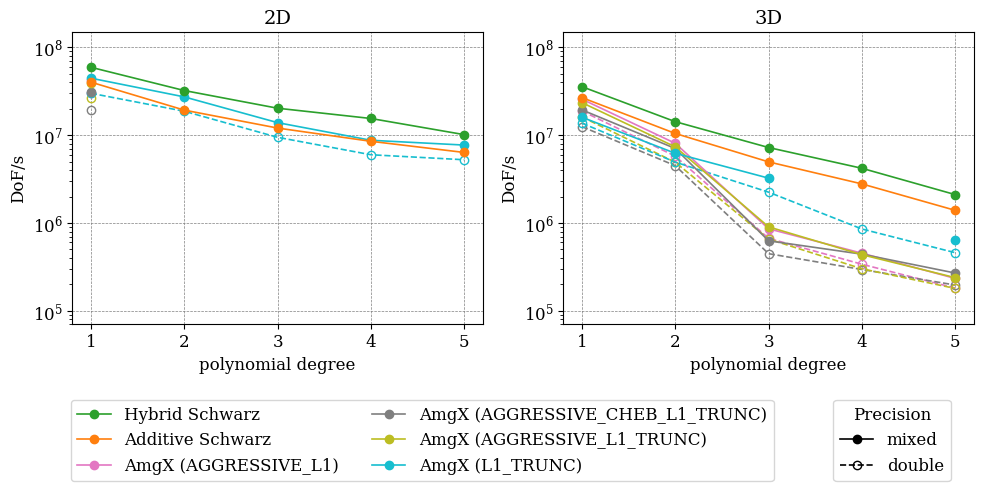

In [14]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, len(tputs.index.levels[0]), figsize=(10, 4), layout="tight")
for i, test_case in enumerate(tputs.index.levels[0]):
    ax = axes[i]
    data = tputs.loc[test_case]
    for solver, (color, line_style) in style_map.items():
        if data[solver].isna().all():
            continue
        label = solver.split(",")[0] + ")" if "AmgX" in solver else solver
        zorder = 5 if "AmgX" in solver else 10
        if line_style == "solid":
            zorder += 1
        ax.plot(
            data.index,
            data[solver],
            marker="o",
            markerfacecolor=color if line_style == "solid" else "none",
            linestyle=line_style,
            color=color,
            label=label if i == 0 and line_style == "solid" else None,
            zorder=zorder,
            linewidth=1.2,
        )
    ax.set_title(test_case.split()[-1])
    ax.set_xlabel("polynomial degree")
    ax.set_ylabel("DoF/s")
    ax.set_yscale("log")
    ax.set_ylim(7e4, 1.5e8)
    ax.grid(which="major", linestyle="--", linewidth=0.5, color="grey")
fig.legend(bbox_to_anchor=(0.43, -0.0), loc="upper center", ncol=2)

fig.legend(
    [
        Line2D([0], [0], color="black", linestyle="solid", linewidth=1.2, marker="o"),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="dashed",
            linewidth=1.2,
            marker="o",
            markerfacecolor="none",
        ),
    ],
    ["mixed", "double"],
    bbox_to_anchor=(0.9, -0.0),
    loc="upper center",
    ncol=1,
    title="Precision",
)

fig.savefig("../docs/images/throughput_vs_amgx.svg", bbox_inches="tight")

## Largest managable problems

In [15]:
problems = (
    df[["test case", "p", "mesh family", "fine m"]]
    .drop_duplicates()
    .sort_values(by=["test case", "p", "mesh family", "fine m"])
    .reset_index(drop=True)
)

problems = problems[~problems["mesh family"].str.contains("unstructured")]

In [16]:
def get_m(mesh):
    return int(mesh[1:])


largest_problems = pd.DataFrame(
    [
        problem
        for _, problem in problems.iterrows()
        if problems[
            (problems["test case"] == problem["test case"])
            & (problems["p"] == problem["p"])
        ]["fine m"]
        .map(get_m)
        .max()
        == get_m(problem["fine m"])
    ]
).reset_index(drop=True)

largest_problems

,test case,p,mesh family,fine m
0,continuous coefficient 2D,1,"uniform(2D,12)",S12
1,continuous coefficient 2D,2,"uniform(2D,11)",S11
2,continuous coefficient 2D,3,"uniform(2D,10)",S10
3,continuous coefficient 2D,4,"uniform(2D,10)",S10
4,continuous coefficient 2D,5,"uniform(2D,9)",S9
5,continuous coefficient 3D,1,"uniform(3D,7)",S7
6,continuous coefficient 3D,2,"uniform(3D,6)",S6
7,continuous coefficient 3D,3,"uniform(3D,5)",S5
8,continuous coefficient 3D,4,"uniform(3D,5)",S5
9,continuous coefficient 3D,5,"uniform(3D,4)",S4


In [17]:
def problem_spec(problem):
    problem_experiments = df[
        (df["test case"] == problem["test case"])
        & (df["p"] == problem["p"])
        & (df["mesh family"] == problem["mesh family"])
        & (df["fine m"] == problem["fine m"])
    ]

    some_experiment = problem_experiments.iloc[0]
    matrix_size = (
        some_experiment["matrix nnz"] * (8 + 4) + (some_experiment["DoFs"] + 1) * 4
    )

    solvable_by_cudss = (
        problem_experiments[problem_experiments["solver"] == "CUDSS"]["exception"]
        .isna()
        .any()
    )

    return pd.Series(
        {
            "$d$": int(problem["test case"].split()[-1][0]),
            "$p$": problem["p"],
            "$\\mathcal{T}_h$": f"${format_mesh(problem['fine m'])}$",
            "{DoFs}": f"{some_experiment['DoFs'] / 1_000_000:.1f}\\,{{M}}",
            "{matrix non-zeros}": f"{some_experiment['matrix nnz'] / 1_000_000_000:.2f}\\,{{G}}",
            "{matrix size}": f"{matrix_size / 1_000_000_000:.2f}\\,{{GB}}",
            "solvable by cuDSS": "yes" if solvable_by_cudss else "no",
        }
    )


largest_problems_table = largest_problems.apply(problem_spec, axis=1).set_index(
    ["$d$", "$p$"]
)
largest_problems_table

$\mathcal{T}_h$      {DoFs} {matrix non-zeros} {matrix size}  \
$d$ $p$                                                                    
2   1    $\mathcal{S}_{12}$  100.7\,{M}          1.21\,{G}   14.90\,{GB}   
    2    $\mathcal{S}_{11}$   50.3\,{M}          1.21\,{G}   14.69\,{GB}   
    3    $\mathcal{S}_{10}$   21.0\,{M}          0.84\,{G}   10.15\,{GB}   
    4    $\mathcal{S}_{10}$   31.5\,{M}          1.89\,{G}   22.76\,{GB}   
    5     $\mathcal{S}_{9}$   11.0\,{M}          0.92\,{G}   11.13\,{GB}   
3   1     $\mathcal{S}_{7}$   50.3\,{M}          1.00\,{G}   12.24\,{GB}   
    2     $\mathcal{S}_{6}$   15.7\,{M}          0.78\,{G}    9.44\,{GB}   
    3     $\mathcal{S}_{5}$    3.9\,{M}          0.39\,{G}    4.68\,{GB}   
    4     $\mathcal{S}_{5}$    6.9\,{M}          1.19\,{G}   14.30\,{GB}   
    5     $\mathcal{S}_{4}$    1.4\,{M}          0.38\,{G}    4.51\,{GB}   

        solvable by cuDSS  
$d$ $p$                    
2   1                  no  
    2                  no  
    3                 yes  
    4                  no  
    5                 yes  
3   1                  no  
    2                  no  
    3                  no  
    4                  no  
    5                 yes

In [18]:
dofs_col = "S[table-format=3.1\\,M]"
matrix_nnz_col = "S[table-format=1.2\\,G]"
matrix_size_col = "S[table-format=2.2\\,GB]"
largest_problems_table_latex = largest_problems_table.style.to_latex(
    hrules=True,
    multirow_align="t",
    multicol_align="c",
    column_format=f"rrc{dofs_col}{matrix_nnz_col}{matrix_size_col}c",
)

In [19]:
latex_lines = largest_problems_table_latex.split("\n")
first_header_line = latex_lines.index("\\toprule") + 1
last_header_line = latex_lines.index("\\midrule") - 1
column_names = [None] * len(latex_lines[first_header_line + 1].split("&"))
for line in latex_lines[first_header_line : last_header_line + 1]:
    line_col_names = [x.strip().removesuffix("\\\\") for x in line.split("&")]
    for i, col_name in enumerate(line_col_names):
        if col_name:
            column_names[i] = col_name
single_header_line = " & ".join(column_names) + " \\\\"
hacked_largest_problems_latex = "\n".join(
    latex_lines[:first_header_line]
    + [single_header_line]
    + latex_lines[last_header_line + 1 :]
)

In [20]:
with open("../docs/tables/largest_problems.tex", "w") as f:
    f.write(hacked_largest_problems_latex)

## Speedup table

In [21]:
def find_best_variants(df: pd.DataFrame) -> pd.DataFrame:
    df = df[df.solver.str.contains("CG")].copy()

    summary = df.pivot_table(
        index=["nice solver"],
        columns=["coarse m", "solvers m"],
        values="best solve time",
        aggfunc="min",
    )
    summary["best"] = summary.min(axis=1)

    if summary.index.str.contains("AmgX").any():
        best_amgx_key = summary["best"][summary.index.str.contains("AmgX")].idxmin()
        best_amgx_variant = best_amgx_key.split("(")[1].split(")")[0]
        best_amgx_time = summary["best"][best_amgx_key]
    else:
        best_amgx_variant = None
        best_amgx_time = None

    best_additive_key = summary["best"][
        summary.index.str.contains("Additive Schwarz")
    ].idxmin()
    best_additive_time = summary["best"][best_additive_key]
    best_additive_by_meshes = summary[
        summary.index.str.contains("Additive Schwarz")
    ].min()
    best_additive_meshing = best_additive_by_meshes.idxmin()

    best_hybrid_key = summary["best"][
        summary.index.str.contains("Hybrid Schwarz")
    ].idxmin()
    best_hybrid_time = summary["best"][best_hybrid_key]
    best_hybrid_by_meshes = summary[summary.index.str.contains("Hybrid Schwarz")].min()
    best_hybrid_meshing = best_hybrid_by_meshes.idxmin()

    return pd.Series(
        {
            "best_amgx_variant": best_amgx_variant,
            "best_amgx_time": best_amgx_time,
            "best_additive_time": best_additive_time,
            "best_additive_meshing": best_additive_meshing,
            "best_hybrid_time": best_hybrid_time,
            "best_hybrid_meshing": best_hybrid_meshing,
        }
    )

In [22]:
def get_problem_summary(problem):
    test_case = problem["test case"]
    p = problem["p"]
    mesh_family = problem["mesh family"]
    fine_m = problem["fine m"]

    data = df[
        (df["test case"] == test_case)
        & (df["p"] == p)
        & (df["fine m"] == fine_m)
        & (df["mesh family"] == mesh_family)
    ]
    if data.empty:
        return pd.Series()

    summary = find_best_variants(data)
    d = int(test_case[-2])
    summary["d"] = d
    summary["mesh family"] = mesh_family
    summary["m"] = fine_m
    summary["p"] = p
    summary["DoFs"] = data["DoFs"].iloc[0]

    return summary

In [23]:
speedup_table = pd.DataFrame(
    get_problem_summary(problem) for _, problem in largest_problems.iterrows()
)
speedup_table

,best_amgx_variant,best_amgx_time,best_additive_time,best_additive_meshing,best_hybrid_time,best_hybrid_meshing,d,mesh family,m,p,DoFs
0,"L1_TRUNC, fp32",2252.932373,2499.763428,"(C10, S11)",1824.602905,"(C11, C12)",2,"uniform(2D,12)",S12,1,100663296
1,"L1_TRUNC, fp32",1840.814453,2603.615723,"(C10, C11)",1557.876221,"(C10, C11)",2,"uniform(2D,11)",S11,2,50331648
2,"L1_TRUNC, fp32",1507.047485,1737.356812,"(S9, S9)",1032.556396,"(C10, C10)",2,"uniform(2D,10)",S10,3,20971520
3,None,NaN,3689.603027,"(C10, S10)",2027.755859,"(C10, C10)",2,"uniform(2D,10)",S10,4,31457280
4,"L1_TRUNC, fp32",1425.344849,1730.400879,"(S9, S9)",1084.872559,"(C9, C9)",2,"uniform(2D,9)",S9,5,11010048
5,"AGGRESSIVE_L1, fp32",1952.959351,1874.077026,"(C6, C7)",1407.375854,"(C6, C7)",3,"uniform(3D,7)",S7,1,50331648
6,"AGGRESSIVE_L1, fp32",1943.803833,1501.115112,"(C5, C6)",1101.878052,"(C5, C6)",3,"uniform(3D,6)",S6,2,15728640
7,"L1_TRUNC, fp32",1212.115356,791.230652,"(C5, C5)",542.874451,"(C5, C5)",3,"uniform(3D,5)",S5,3,3932160
8,"L1_TRUNC, fp64",8055.961914,2468.267090,"(C5, S5)",1638.029175,"(C5, C5)",3,"uniform(3D,5)",S5,4,6881280
9,"L1_TRUNC, fp32",2137.782959,987.618103,"(C4, C4)",653.890198,"(C4, C4)",3,"uniform(3D,4)",S4,5,1376256


In [24]:
tab = pd.DataFrame()
tab[["$d$", "$p$"]] = speedup_table[["d", "p"]]
tab["$\\mathcal{T}_h$"] = speedup_table["m"].apply(lambda m: f"${format_mesh(m)}$")
# tab["DoFs"] = speedup_table["DoFs"].apply(lambda n: f"{n / 1_000_000:.1f}\\,{{M}}")

amgx_best = "best AmgX configuration found"
hybrid_best = "best hybrid Schwarz variant"

tab[(amgx_best, "name")] = speedup_table["best_amgx_variant"].map(
    lambda v: f"\\verb|{v}|" if pd.notna(v) else "{--}"
)
tab[(amgx_best, "time")] = speedup_table["best_amgx_time"] / 1000

tab[(hybrid_best, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_hybrid_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab[(hybrid_best, "$\\mathcal{T}_H$")] = speedup_table["best_hybrid_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab[(hybrid_best, "time")] = speedup_table["best_hybrid_time"] / 1000
tab[(hybrid_best, "speedup")] = tab[(amgx_best, "time")] / tab[(hybrid_best, "time")]

tab.set_index(["$d$", "$p$", "$\\mathcal{T}_h$"], inplace=True)


def time_latex(t: float):
    return f"{t:.6f}\\, \\si{{\\second}}" if pd.notna(t) else "{--}"


def speedup_latex(s: float):
    return f"{s:.6f} \\,\\(\\times\\)" if pd.notna(s) else "{$\\infty\\,\\times$}"


tab[(amgx_best, "time")] = tab[(amgx_best, "time")].apply(time_latex)
tab[(hybrid_best, "time")] = tab[(hybrid_best, "time")].apply(time_latex)
tab[(hybrid_best, "speedup")] = tab[(hybrid_best, "speedup")].apply(speedup_latex)

tab.columns = pd.MultiIndex.from_tuples(tab.columns)
tab.rename(columns=lambda c: f"{{{c}}}", inplace=True)
tab

{best AmgX configuration found}  \
                                                    {name}   
$d$ $p$ $\mathcal{T}_h$                                      
2   1   $\mathcal{S}_{12}$           \verb|L1_TRUNC, fp32|   
    2   $\mathcal{S}_{11}$           \verb|L1_TRUNC, fp32|   
    3   $\mathcal{S}_{10}$           \verb|L1_TRUNC, fp32|   
    4   $\mathcal{S}_{10}$                            {--}   
    5   $\mathcal{S}_{9}$            \verb|L1_TRUNC, fp32|   
3   1   $\mathcal{S}_{7}$       \verb|AGGRESSIVE_L1, fp32|   
    2   $\mathcal{S}_{6}$       \verb|AGGRESSIVE_L1, fp32|   
    3   $\mathcal{S}_{5}$            \verb|L1_TRUNC, fp32|   
    4   $\mathcal{S}_{5}$            \verb|L1_TRUNC, fp64|   
    5   $\mathcal{S}_{4}$            \verb|L1_TRUNC, fp32|   

                                                     \
                                             {time}   
$d$ $p$ $\mathcal{T}_h$                               
2   1   $\mathcal{S}_{12}$  2.252932\, \si{\second}   
    2   $\mathcal{S}_{11}$  1.840814\, \si{\second}   
    3   $\mathcal{S}_{10}$  1.507047\, \si{\second}   
    4   $\mathcal{S}_{10}$                     {--}   
    5   $\mathcal{S}_{9}$   1.425345\, \si{\second}   
3   1   $\mathcal{S}_{7}$   1.952959\, \si{\second}   
    2   $\mathcal{S}_{6}$   1.943804\, \si{\second}   
    3   $\mathcal{S}_{5}$   1.212115\, \si{\second}   
    4   $\mathcal{S}_{5}$   8.055962\, \si{\second}   
    5   $\mathcal{S}_{4}$   2.137783\, \si{\second}   

                           {best hybrid Schwarz variant}                      \
                             {$\mathcal{T}_\mathcal{H}$}   {$\mathcal{T}_H$}   
$d$ $p$ $\mathcal{T}_h$                                                        
2   1   $\mathcal{S}_{12}$            $\mathcal{C}_{11}$  $\mathcal{C}_{12}$   
    2   $\mathcal{S}_{11}$            $\mathcal{C}_{10}$  $\mathcal{C}_{11}$   
    3   $\mathcal{S}_{10}$            $\mathcal{C}_{10}$  $\mathcal{C}_{10}$   
    4   $\mathcal{S}_{10}$            $\mathcal{C}_{10}$  $\mathcal{C}_{10}$   
    5   $\mathcal{S}_{9}$              $\mathcal{C}_{9}$   $\mathcal{C}_{9}$   
3   1   $\mathcal{S}_{7}$              $\mathcal{C}_{6}$   $\mathcal{C}_{7}$   
    2   $\mathcal{S}_{6}$              $\mathcal{C}_{5}$   $\mathcal{C}_{6}$   
    3   $\mathcal{S}_{5}$              $\mathcal{C}_{5}$   $\mathcal{C}_{5}$   
    4   $\mathcal{S}_{5}$              $\mathcal{C}_{5}$   $\mathcal{C}_{5}$   
    5   $\mathcal{S}_{4}$              $\mathcal{C}_{4}$   $\mathcal{C}_{4}$   

                                                                            
                                             {time}              {speedup}  
$d$ $p$ $\mathcal{T}_h$                                                     
2   1   $\mathcal{S}_{12}$  1.824603\, \si{\second}  1.234752 \,\(\times\)  
    2   $\mathcal{S}_{11}$  1.557876\, \si{\second}  1.181618 \,\(\times\)  
    3   $\mathcal{S}_{10}$  1.032556\, \si{\second}  1.459530 \,\(\times\)  
    4   $\mathcal{S}_{10}$  2.027756\, \si{\second}     {$\infty\,\times$}  
    5   $\mathcal{S}_{9}$   1.084873\, \si{\second}  1.313836 \,\(\times\)  
3   1   $\mathcal{S}_{7}$   1.407376\, \si{\second}  1.387660 \,\(\times\)  
    2   $\mathcal{S}_{6}$   1.101878\, \si{\second}  1.764083 \,\(\times\)  
    3   $\mathcal{S}_{5}$   0.542874\, \si{\second}  2.232773 \,\(\times\)  
    4   $\mathcal{S}_{5}$   1.638029\, \si{\second}  4.918082 \,\(\times\)  
    5   $\mathcal{S}_{4}$   0.653890\, \si{\second}  3.269330 \,\(\times\)

In [31]:
time_col = "S[table-format=1.2\\,s, round-mode=places, round-precision=2]"
speedup_col = "S[table-format=1.2, round-mode=places, round-precision=2]"
# dofs_col = "S[table-format=2.1\\,M]"
tab_latex = tab.style.to_latex(
    hrules=True,
    multirow_align="t",
    multicol_align="c",
    column_format=f"rrc|l{time_col}|cc{time_col}{speedup_col}",
)

In [32]:
custom_header = r"""
 &  &  & \multicolumn{2}{c|}{{best AmgX configuration found}} & \multicolumn{4}{c}{{best hybrid variant considered}} \\
$d$ & $p$ & $\mathcal{T}_h$ & {name} & {time} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} \\
"""

before_header = tab_latex.split("\\toprule")[0] + "\\toprule\n"
after_header = "\n\\midrule\n" + tab_latex.split("\\midrule")[1]
hacked_latex = before_header + custom_header + after_header
hacked_latex = hacked_latex.replace(
    "\\multirow[t]{3}{*}{3}", "\\midrule\n\\multirow[t]{3}{*}{3}"
)

In [33]:
with open("../docs/tables/experiment_speedups.tex", "w") as f:
    f.write(hacked_latex)